# Phase B — Nucleus Segmentation

**Dataset:** WARD00034-R2 (`5c6bf125`), 249,465 nuclei (MIN_AREA=400)
**Parquet:** `outputs/run_20260806_141727_cyq9/nuclei_features/`

> **Note:** `hs_array_nucleus_segmentation_walkthrough.ipynb` in this directory
> contains the full algorithmic deep-dive (per-object Otsu, all intermediates,
> MIN_AREA diagnostic). This notebook focuses on the production outputs and QC.

Steps: metadata loading · representative field · segmentation sub-steps · QC summary

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt, matplotlib.colors as mc
from scipy.stats import norm
from skimage import filters, morphology
from skimage.measure import label as sklabel, regionprops_table
from skimage.segmentation import find_boundaries
from skimage.color import label2rgb

REPO    = Path('/Users/pmihack/claire/hs-array')
UUID    = '5c6bf125-6e0f-41be-a447-b03ff294c9cc'
RUN_DIR = REPO / 'outputs/run_20260806_141727_cyq9'
NUC_PAR = RUN_DIR / f'nuclei_features/{UUID}_nuclei_features.parquet'
QC_PAR  = RUN_DIR / f'nuclei_features/{UUID}_image_qc.parquet'
IMG_DIR = REPO / 'data/D28_AB_Rep1' / UUID / 'images'
FIGDIR  = Path('/Users/pmihack/claire/hs-array/resources/iNDI_microscopy_production/notebooks/figures/phase_B')
FIGDIR.mkdir(parents=True, exist_ok=True)

PX_UM = 0.2967; Z_UM = 1.997; DPI = 300; BG = 'black'; FG = 'white'
MIN_AREA = 400   # px² (corrected for 0.2967 µm/px)

def _p(img, lo=0.5, hi=99.5):
    return np.percentile(img.astype(np.float32), lo), np.percentile(img.astype(np.float32), hi)

## Step 4 — Load Metadata and Pick a Representative Field

In [2]:
df = pd.read_parquet(NUC_PAR)
df['area_um2'] = df['area'] * PX_UM**2

print(f"Total nuclei: {len(df):,}")
print(f"Unique wells: {df[['Row','Column']].drop_duplicates().shape[0]}")
print(f"Unique sites: {df[['Row','Column','Frame']].drop_duplicates().shape[0]}")
print(f"Channels in parquet: {df['Channel_name'].unique()}")
print()
print(df[['Row','Column','Frame','area','area_um2','centroid-0','centroid-1',
          'intensity_max','solidity']].head(3).to_string())

site_counts = df.groupby(['Row','Column','Frame']).size().reset_index(name='n')
well_totals = df.groupby(['Row','Column']).size().reset_index(name='well_n')

# Pick center-plate well (rows 5-12, cols 5-18), frame 5 (center of 3x3 grid), ≥10 nuclei/site
cand = (site_counts
        .merge(well_totals, on=['Row','Column'])
        .query("Frame==5 and n>=10 and well_n>=65 and Row>=5 and Row<=12 and Column>=5 and Column<=18")
        .sort_values('n', ascending=False))

if cand.empty:
    cand = site_counts.merge(well_totals, on=['Row','Column']).query("n>=10 and well_n>=65").sort_values('n', ascending=False)

r0 = cand.iloc[0]
WT_ROW, WT_COL, WT_FRAME = int(r0.Row), int(r0.Column), int(r0.Frame)
print(f"\nWalkthrough site: r{WT_ROW:02d}c{WT_COL:02d} frame={WT_FRAME}  "
      f"({r0.n} nuclei/site, {r0.well_n} nuclei/well)")

Total nuclei: 249,465
Unique wells: 192
Unique sites: 1728
Channels in parquet: <ArrowStringArray>
['DAPI']
Length: 1, dtype: str

   Row  Column  Frame   area   area_um2  centroid-0   centroid-1  intensity_max  solidity
0    3       3      1  651.0  57.308109   15.302611   215.105991        45536.0  0.950365
1    3       3      1  511.0  44.983785    8.878669   507.232877        27237.0  0.955140
2    3       3      1  529.0  46.568341    9.328922  1351.041588         6848.0  0.685233

Walkthrough site: r07c05 frame=5  (350 nuclei/site, 2481 nuclei/well)


## Step 5 — Nucleus Segmentation Pipeline

In [3]:
# Load DAPI z-stack for the chosen site
subdir = IMG_DIR / f'r{WT_ROW:02d}c{WT_COL:02d}'
plane_paths = sorted(subdir.glob(f'r{WT_ROW:02d}c{WT_COL:02d}f{WT_FRAME:02d}p*-ch01t01.tiff'))
planes = [tifffile.imread(p).astype(np.float32) for p in plane_paths]
print(f"Loaded {len(planes)} z-planes for r{WT_ROW:02d}c{WT_COL:02d} f{WT_FRAME:02d}")

# ── Sub-step a: MIP
mip = np.max(np.stack(planes), axis=0)

# ── Sub-step b: Gaussian-fit contrast stretch [µ-1σ … µ+7σ → 0…1]
m, s = norm.fit(mip.flatten())
stretch_min = max(m - 1*s, mip.min())
stretch_max = min(m + 7*s, mip.max())
image_norm = (np.clip(mip, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min)

# ── Sub-step c: Gaussian blur σ=1
blurred = filters.gaussian(image_norm, sigma=1)

# ── Sub-step d: Otsu threshold (production uses (triangle+p50)/2; Otsu shown for clarity)
th_otsu  = filters.threshold_otsu(blurred)
triangle = filters.threshold_triangle(blurred)
p50      = np.percentile(blurred, 50)
th_low   = (triangle + p50) / 2
mask_low = morphology.remove_small_objects(blurred > th_low, min_size=MIN_AREA)
mask_low = morphology.dilation(mask_low, footprint=morphology.disk(2))

# ── Sub-step e: label + regionprops
labeled_raw = sklabel(mask_low)
n_raw = labeled_raw.max()

# ── Sub-step f: QC filters (area, edge exclusion, max-DAPI)
from skimage.measure import regionprops
props = regionprops(labeled_raw, intensity_image=mip)
H, W = mip.shape
EDGE = 20
MAX_AREA_PX2 = 2270  # 200 µm² at 0.2967 µm/px

keep_labels = []
for p in props:
    y0, x0, y1, x1 = p.bbox
    if (y0 < EDGE or x0 < EDGE or y1 > H-EDGE or x1 > W-EDGE):
        continue
    if p.area < MIN_AREA or p.area > MAX_AREA_PX2:
        continue
    if p.intensity_max < 500:
        continue
    keep_labels.append(p.label)

mask_final = np.isin(labeled_raw, keep_labels)
labeled_final = sklabel(mask_final)
n_final = labeled_final.max()

print(f"\nSub-step a (MIP): {mip.shape} uint16")
print(f"Sub-step b (stretch): raw [{mip.min():.0f},{mip.max():.0f}] → clip [{stretch_min:.0f},{stretch_max:.0f}] (µ={m:.0f}, σ={s:.0f})")
print(f"Sub-step c (blur): σ=1")
print(f"Sub-step d (threshold): (triangle={triangle:.3f} + p50={p50:.3f})/2 = {th_low:.3f}")
print(f"Sub-step e (label): {n_raw} raw blobs")
print(f"Sub-step f (QC): {n_raw} → {n_final} nuclei  (area {MIN_AREA}–{MAX_AREA_PX2} px², edge excl., max-DAPI>500)")

Loaded 10 z-planes for r07c05 f05

Sub-step a (MIP): (2160, 2160) uint16
Sub-step b (stretch): raw [107,65535] → clip [107,24720] (µ=1204, σ=3359)
Sub-step c (blur): σ=1
Sub-step d (threshold): (triangle=0.014 + p50=0.002)/2 = 0.008
Sub-step e (label): 151 raw blobs
Sub-step f (QC): 151 → 52 nuclei  (area 400–2270 px², edge excl., max-DAPI>500)


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_66867/2323603655.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_low = morphology.remove_small_objects(blurred > th_low, min_size=MIN_AREA)


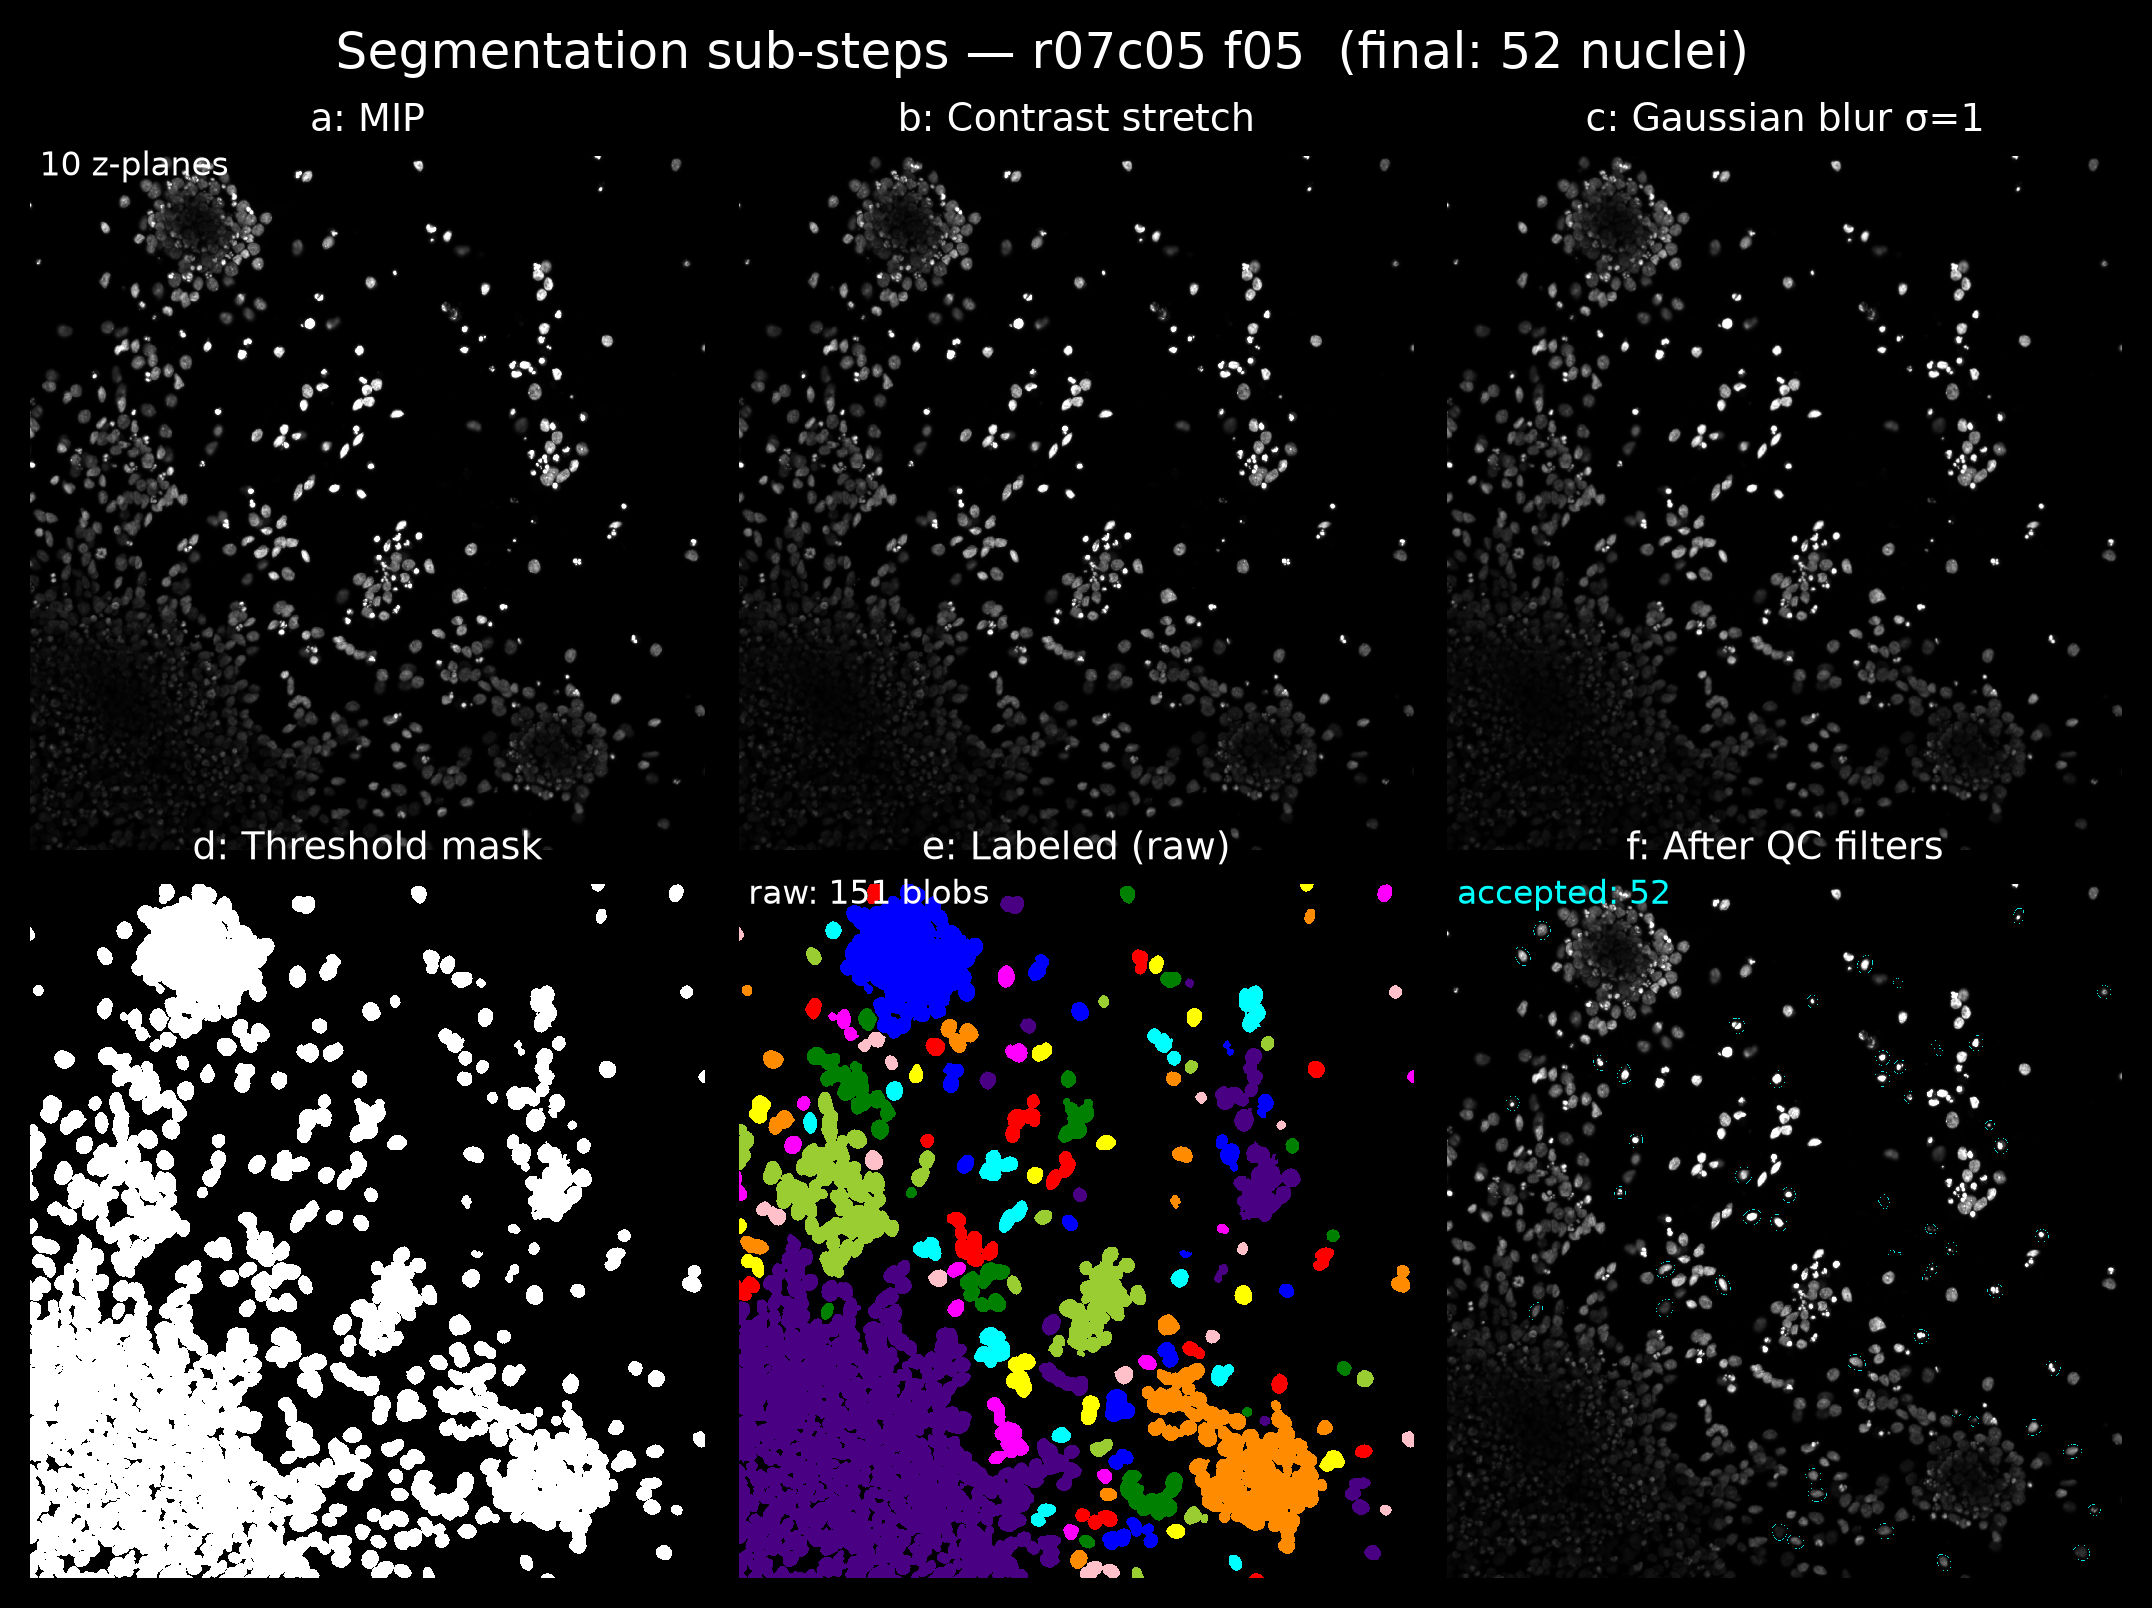

Saved: 01_segmentation_steps.png


In [4]:
# Show all 6 sub-steps in one figure
from skimage.color import label2rgb as l2rgb

panels = [
    ('a: MIP', mip, 'gray'),
    ('b: Contrast stretch', image_norm, 'gray'),
    ('c: Gaussian blur σ=1', blurred, 'gray'),
    ('d: Threshold mask', mask_low.astype(float), 'gray'),
    ('e: Labeled (raw)', None, None),
    ('f: After QC filters', None, None),
]

fig, axs = plt.subplots(2, 3, figsize=(9.0, 6.0), facecolor=BG, dpi=DPI)
fig.suptitle(f'Segmentation sub-steps — r{WT_ROW:02d}c{WT_COL:02d} f{WT_FRAME:02d}  '
             f'(final: {n_final} nuclei)', color=FG, y=0.97)
plt.subplots_adjust(hspace=0.05, wspace=0.05, top=0.90)

vmin_raw, vmax_raw = _p(mip)
for ax, (title, img, cmap) in zip(axs.flat, panels):
    ax.set_facecolor(BG); ax.axis('off')
    for s in ax.spines.values(): s.set_color(FG)
    ax.set_title(title, color=FG, fontsize=9)
    if title.startswith('e:'):
        ax.imshow(l2rgb(labeled_raw, bg_label=0), aspect='auto', interpolation='none')
    elif title.startswith('f:'):
        # Show accepted nuclei boundaries on MIP
        bd = find_boundaries(labeled_final, mode='outer')
        ax.imshow(mip, cmap='gray', vmin=vmin_raw, vmax=vmax_raw, aspect='auto', interpolation='none')
        overlay = np.zeros((*mip.shape, 4), dtype=np.float32)
        overlay[bd] = [0, 1, 1, 0.9]  # cyan outlines
        ax.imshow(overlay, interpolation='none', aspect='auto')
    elif img is mip:
        ax.imshow(img, cmap=cmap, vmin=vmin_raw, vmax=vmax_raw, aspect='auto', interpolation='none')
    elif img is not None:
        vmin, vmax = (0, 1) if img.max() <= 1.0 else _p(img)
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')

# Add nucleus count annotation
axs[0,0].text(30, 60, f'{len(planes)} z-planes', color=FG, fontsize=8)
axs[1,1].text(30, 60, f'raw: {n_raw} blobs', color=FG, fontsize=8)
axs[1,2].text(30, 60, f'accepted: {n_final}', color='cyan', fontsize=8)

fig.savefig(FIGDIR / '01_segmentation_steps.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 01_segmentation_steps.png")

## Step 6 — R1 vs R2 Segmentation Difference

| | Round 1 (R1) | Round 2 (R2) |
|---|---|---|
| Segmentation channel | ch01 = **BFP** (405 nm, cytosolic dye) | ch01 = **DAPI** (405 nm, nuclear stain) |
| Signal shape | Fills entire cell soma | Confined to nucleus |
| MIP appearance | Bright filled soma | Sharp nuclear ring |
| Nucleus detection | Works (soma fills nucleus region) | Works (direct nuclear signal) |
| N:C interpretation | **Not comparable to R2** — BFP is cytosolic, not nuclear | Primary readout: TDP-43 N:C ratio |

**Consequence:** R1 TDP-43 intensity values are valid, but the N:C ratio denominator
(cytoplasm = BFP soma) is not the same as R2 (cytoplasm = annular ring around DAPI nucleus).
R1 and R2 N:C values must NOT be compared directly without cross-round registration.

> WARD00034 R1 TIFF data is not on disk — see WARD00026/27 R1 data for comparison.

## QC Summary — Image QC Parquet

Image QC parquet: 1728 rows (= 192 wells × 9 fields)
Columns: ['Row', 'Column', 'Frame', 'n_planes', 'n_nuclei', 'filter_status', 'contrast_check', 'ChannelID', 'Time', 'Channel_name', 'Type', 'Excitation_nm', 'Emission_nm', 'Pseudocolor', 'Measurement_ID', 'Measurement_date', 'Plate_ID', 'res_x', 'res_y', 'Experiment_name']

Filter status:
filter_status
pass    1728

Contrast check:
contrast_check
pass    1728


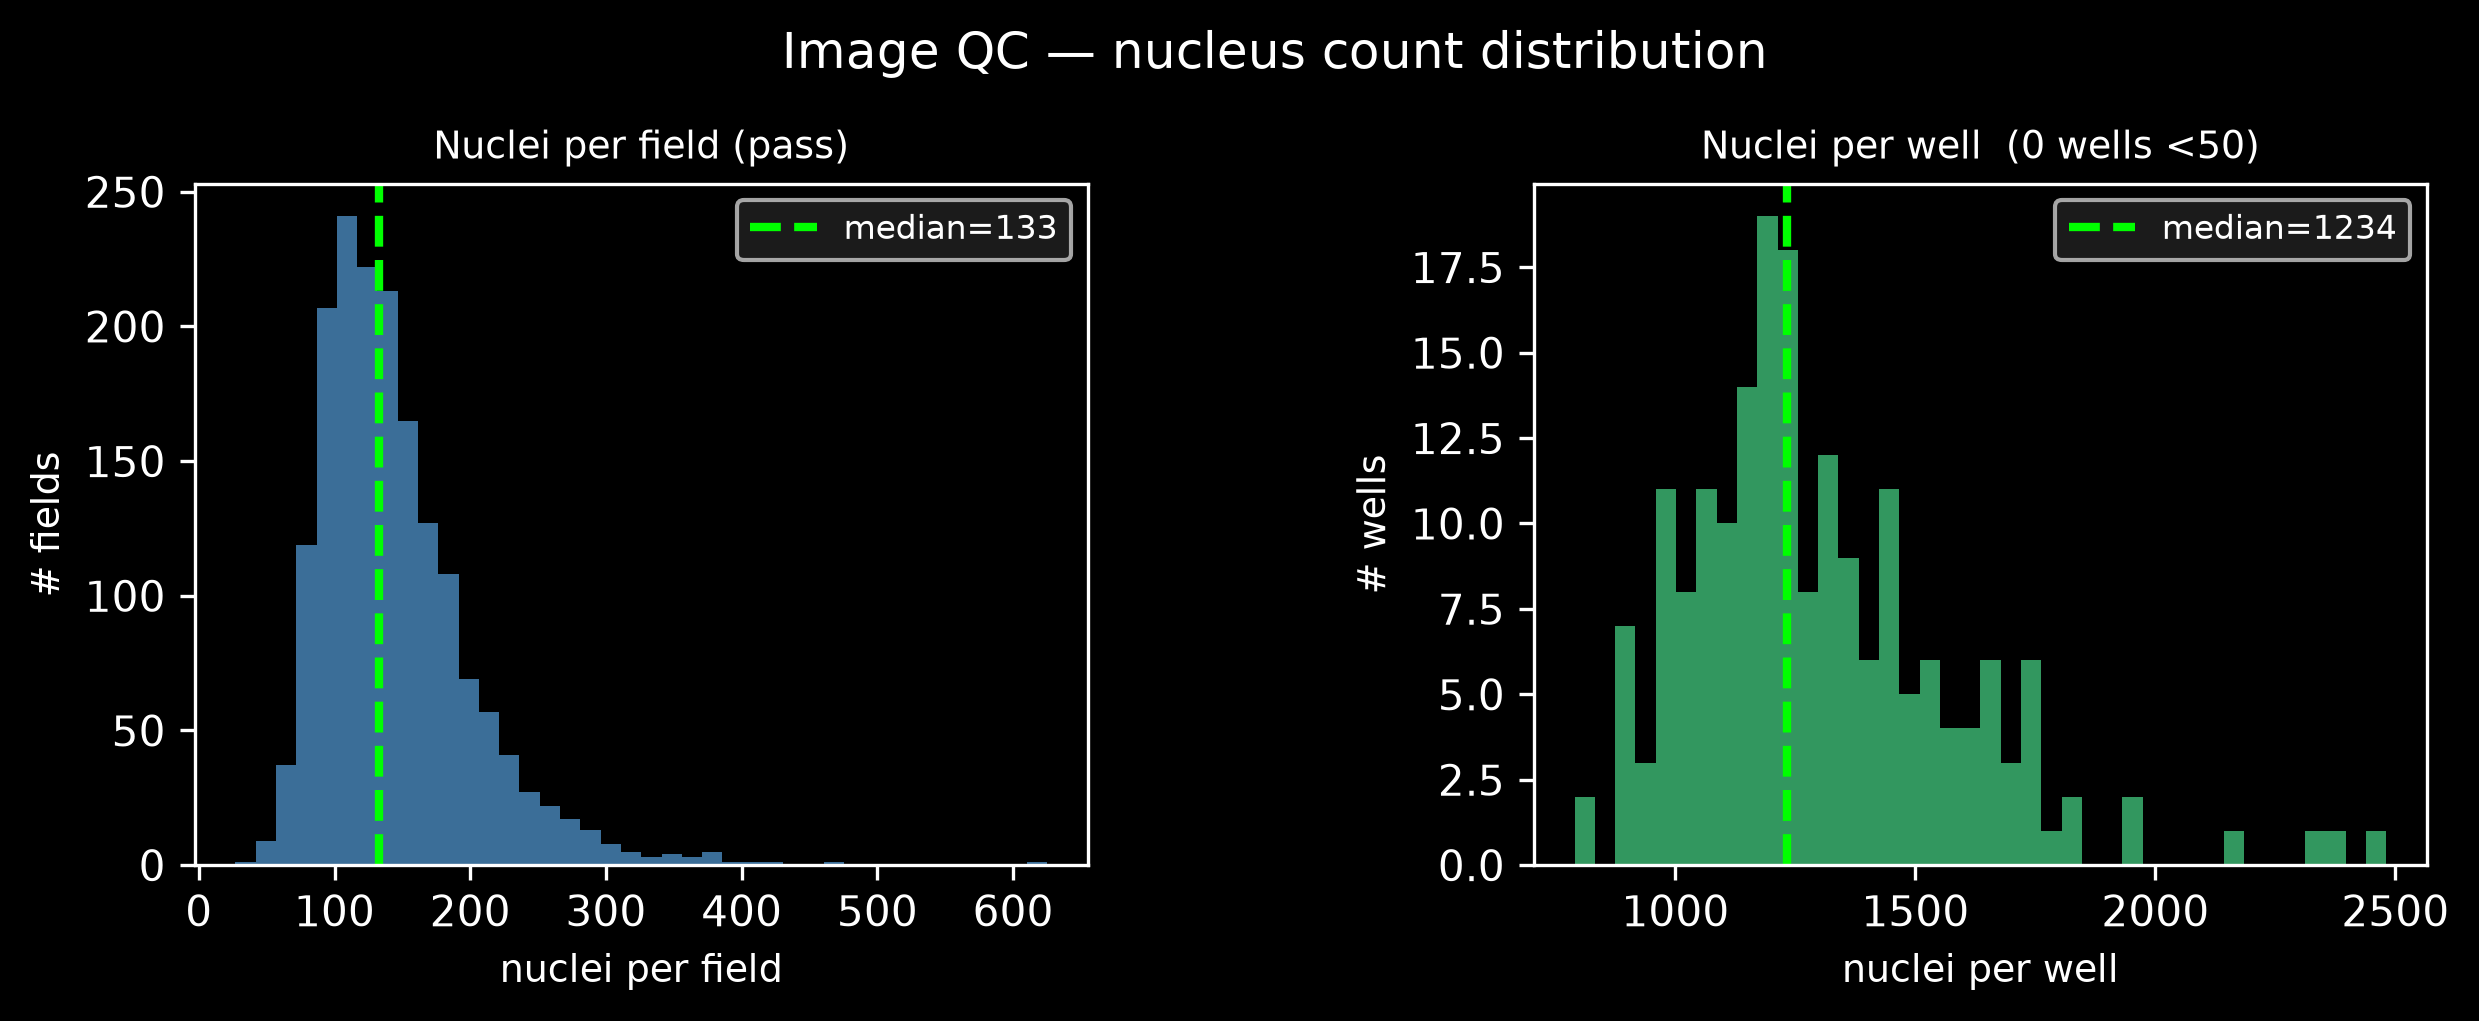


No wells with <50 nuclei — all wells pass.


In [5]:
qc = pd.read_parquet(QC_PAR)
print(f"Image QC parquet: {len(qc)} rows (= {len(qc)//9} wells × 9 fields)")
print(f"Columns: {list(qc.columns)}")
print()

print("Filter status:")
print(qc.filter_status.value_counts().to_string())
print()
print("Contrast check:")
print(qc.contrast_check.value_counts().to_string())

fig, axs = plt.subplots(1, 2, figsize=(9.6, 3.2), facecolor=BG, dpi=DPI)
fig.suptitle('Image QC — nucleus count distribution', color=FG)
for ax in axs:
    ax.set_facecolor(BG); ax.tick_params(colors=FG)
    ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)
    for s in ax.spines.values(): s.set_color(FG)

qc_pass = qc[qc.filter_status == 'pass']
axs[0].hist(qc_pass.n_nuclei, bins=40, color='steelblue', alpha=0.85, edgecolor='none')
axs[0].axvline(qc_pass.n_nuclei.median(), color='lime', ls='--', lw=2,
               label=f'median={qc_pass.n_nuclei.median():.0f}')
axs[0].set_xlabel('nuclei per field', fontsize=9)
axs[0].set_ylabel('# fields', fontsize=9)
axs[0].set_title('Nuclei per field (pass)', color=FG, fontsize=9)
axs[0].legend(fontsize=8, labelcolor=FG, facecolor='#222')

well_n = qc_pass.groupby(['Row', 'Column'])['n_nuclei'].sum()
low_wells = (well_n < 50).sum()
axs[1].hist(well_n, bins=40, color='mediumseagreen', alpha=0.85, edgecolor='none')
axs[1].axvline(well_n.median(), color='lime', ls='--', lw=2,
               label=f'median={well_n.median():.0f}')
axs[1].set_xlabel('nuclei per well', fontsize=9)
axs[1].set_ylabel('# wells', fontsize=9)
axs[1].set_title(f'Nuclei per well  ({low_wells} wells <50)', color=FG, fontsize=9)
axs[1].legend(fontsize=8, labelcolor=FG, facecolor='#222')

fig.subplots_adjust(wspace=0.50, top=0.82)
fig.savefig(FIGDIR / '02_qc_nucleus_counts.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()

low = well_n[well_n < 50].reset_index()
if len(low) > 0:
    low['well'] = low.Row.apply(lambda r: chr(64 + int(r))) + low.Column.apply(str)
    print(f"\nWells with <50 nuclei ({len(low)}):")
    print(low[['well', 'n_nuclei']].to_string(index=False))
else:
    print("\nNo wells with <50 nuclei — all wells pass.")

In [6]:
# Verify figures
pngs = sorted(FIGDIR.glob('*.png'))
empty = [p for p in pngs if p.stat().st_size == 0]
assert pngs,  f"No figures written to {FIGDIR}"
assert not empty, f"0-byte figures: {empty}"
print(f"OK: {len(pngs)} figures in {FIGDIR.name}/")
for p in pngs:
    print(f"  {p.name}  ({p.stat().st_size//1024} KB)")

OK: 2 figures in phase_B/
  01_segmentation_steps.png  (892 KB)
  02_qc_nucleus_counts.png  (97 KB)
